In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import combinations
from statsmodels.tsa.stattools import coint

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# BASELINE PARAMETERS
BASE_CORR_THRESHOLD = 0.80
BASE_COINT_PVALUE = 0.05
BASE_FORMATION_WINDOW = 252
BASE_TRADING_WINDOW = 63
BASE_ENTRY_Z = 2.0
BASE_EXIT_Z = 0.5
BASE_FIXED_BPS = 5
BASE_COST_MODEL = "bid_ask"   # primary model
ANNUALIZATION = 252

TRADE_UNIVERSE = [
    "SPY US Equity", "QQQ US Equity", "IWM US Equity", "DIA US Equity",
    "XLB US Equity", "XLE US Equity", "XLF US Equity", "XLI US Equity",
    "XLK US Equity", "XLP US Equity", "XLU US Equity", "XLV US Equity",
    "XLY US Equity", "SHY US Equity", "IEF US Equity", "TLT US Equity",
    "TIP US Equity", "LQD US Equity", "HYG US Equity", "EFA US Equity",
    "EEM US Equity", "GLD US Equity", "SLV US Equity", "IWF US Equity",
    "IWD US Equity"
]

In [123]:
raw_path = Path("../data_raw/bloomberg_raw_etf_2010_2025.csv")
raw_path.exists()

True

In [124]:
df_raw = pd.read_csv(raw_path)
df_raw.head()

C:\Users\Zhaniya\AppData\Local\Temp\ipykernel_22160\2578083909.py:1: DtypeWarning: Columns (0: Unnamed: 1, 1: Unnamed: 2, 2: Unnamed: 3, 3: Unnamed: 4, 4: Unnamed: 7, 5: Unnamed: 8, 6: Unnamed: 9, 7: Unnamed: 10, 8: Unnamed: 13, 9: Unnamed: 14, 10: Unnamed: 15, 11: Unnamed: 16, 12: Unnamed: 19, 13: Unnamed: 20, 14: Unnamed: 21, 15: Unnamed: 22, 16: Unnamed: 25, 17: Unnamed: 26, 18: Unnamed: 27, 19: Unnamed: 28, 20: Unnamed: 31, 21: Unnamed: 32, 22: Unnamed: 33, 23: Unnamed: 34, 24: Unnamed: 37, 25: Unnamed: 38, 26: Unnamed: 39, 27: Unnamed: 40, 28: Unnamed: 43, 29: Unnamed: 44, 30: Unnamed: 45, 31: Unnamed: 46, 32: Unnamed: 49, 33: Unnamed: 50, 34: Unnamed: 51, 35: Unnamed: 52, 36: Unnamed: 55, 37: Unnamed: 56, 38: Unnamed: 57, 39: Unnamed: 58, 40: Unnamed: 61, 41: Unnamed: 62, 42: Unnamed: 63, 43: Unnamed: 64, 44: Unnamed: 67, 45: Unnamed: 68, 46: Unnamed: 69, 47: Unnamed: 70, 48: Unnamed: 73, 49: Unnamed: 74, 50: Unnamed: 75, 51: Unnamed: 76, 52: Unnamed: 79, 53: Unnamed: 80, 54: Unn

,SPY US Equity,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,QQQ US Equity,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,IWM US Equity,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,DIA US Equity,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,VTI US Equity,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,XLB US Equity,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,XLE US Equity,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,XLF US Equity,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,XLI US Equity,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,XLK US Equity,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,XLP US Equity,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,XLU US Equity,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,XLV US Equity,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,XLY US Equity,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,XLRE US Equity,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,SHY US Equity,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94,Unnamed: 95,IEF US Equity,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,TLT US Equity,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106,Unnamed: 107,TIP US Equity,Unnamed: 109,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,LQD US Equity,Unnamed: 115,Unnamed: 116,Unnamed: 117,Unnamed: 118,Unnamed: 119,HYG US Equity,Unnamed: 121,Unnamed: 122,Unnamed: 123,Unnamed: 124,Unnamed: 125,EFA US Equity,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,EEM US Equity,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136,Unnamed: 137,IWF US Equity,Unnamed: 139,Unnamed: 140,Unnamed: 141,Unnamed: 142,Unnamed: 143,IWD US Equity,Unnamed: 145,Unnamed: 146,Unnamed: 147,Unnamed: 148,Unnamed: 149,MTUM US Equity,Unnamed: 151,Unnamed: 152,Unnamed: 153,Unnamed: 154,Unnamed: 155,QUAL US Equity,Unnamed: 157,Unnamed: 158,Unnamed: 159,Unnamed: 160,Unnamed: 161,GLD US Equity,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,SLV US Equity,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,VIX Index,Unnamed: 175,Unnamed: 176,Unnamed: 177,Unnamed: 178
0,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume
1,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,

In [125]:
print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

Shape: (4175, 179)

Columns:
['SPY US Equity', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'QQQ US Equity', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'IWM US Equity', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'DIA US Equity', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'VTI US Equity', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'XLB US Equity', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'XLE US Equity', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'XLF US Equity', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'XLI US Equity', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'XLK US Equity', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'XLP US Equity', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 6

In [126]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df_raw.head(20)

,SPY US Equity,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,QQQ US Equity,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,IWM US Equity,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,DIA US Equity,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,VTI US Equity,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,XLB US Equity,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,XLE US Equity,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,XLF US Equity,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,XLI US Equity,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,XLK US Equity,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,XLP US Equity,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,XLU US Equity,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,XLV US Equity,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,XLY US Equity,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,XLRE US Equity,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,SHY US Equity,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94,Unnamed: 95,IEF US Equity,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,TLT US Equity,Unnamed: 103,Unnamed: 104,Unnamed: 105,Unnamed: 106,Unnamed: 107,TIP US Equity,Unnamed: 109,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,LQD US Equity,Unnamed: 115,Unnamed: 116,Unnamed: 117,Unnamed: 118,Unnamed: 119,HYG US Equity,Unnamed: 121,Unnamed: 122,Unnamed: 123,Unnamed: 124,Unnamed: 125,EFA US Equity,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,EEM US Equity,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136,Unnamed: 137,IWF US Equity,Unnamed: 139,Unnamed: 140,Unnamed: 141,Unnamed: 142,Unnamed: 143,IWD US Equity,Unnamed: 145,Unnamed: 146,Unnamed: 147,Unnamed: 148,Unnamed: 149,MTUM US Equity,Unnamed: 151,Unnamed: 152,Unnamed: 153,Unnamed: 154,Unnamed: 155,QUAL US Equity,Unnamed: 157,Unnamed: 158,Unnamed: 159,Unnamed: 160,Unnamed: 161,GLD US Equity,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,SLV US Equity,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,VIX Index,Unnamed: 175,Unnamed: 176,Unnamed: 177,Unnamed: 178
0,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume,NaN,Dates,Last Price,Bid Price,Ask Price,Volume
1,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,NaN,NaN,NaN,NaN,01/01/2010,NaN,

In [127]:
df_raw.dtypes

SPY US Equity       str
Unnamed: 1       object
Unnamed: 2       object
Unnamed: 3       object
Unnamed: 4       object
                  ...  
VIX Index           str
Unnamed: 175     object
Unnamed: 176        str
Unnamed: 177        str
Unnamed: 178        str
Length: 179, dtype: object

In [128]:
first_row = df_raw.iloc[0]
first_row

SPY US Equity         Dates
Unnamed: 1       Last Price
Unnamed: 2        Bid Price
Unnamed: 3        Ask Price
Unnamed: 4           Volume
                    ...    
VIX Index             Dates
Unnamed: 175     Last Price
Unnamed: 176      Bid Price
Unnamed: 177      Ask Price
Unnamed: 178         Volume
Name: 0, Length: 179, dtype: object

In [129]:
records = []

n_cols = df_raw.shape[1]

for start in range(0, n_cols, 6):
    block_cols = df_raw.columns[start:start+6]
    
    if len(block_cols) < 5:
        continue
    
    ticker_col = block_cols[0]
    px_col = block_cols[1]
    bid_col = block_cols[2]
    ask_col = block_cols[3]
    vol_col = block_cols[4]
    
    ticker = ticker_col
    
    temp = df_raw.iloc[1:, [start, start+1, start+2, start+3, start+4]].copy()
    temp.columns = ["date", "px_last", "bid", "ask", "volume"]
    temp["ticker"] = ticker
    
    records.append(temp)

tidy_df = pd.concat(records, ignore_index=True)
tidy_df.head()

,date,px_last,bid,ask,volume,ticker
0,01/01/2010,NaN,NaN,NaN,NaN,SPY US Equity
1,04/01/2010,113.33,NaN,NaN,118944541,SPY US Equity
2,05/01/2010,113.63,NaN,NaN,111579866,SPY US Equity
3,06/01/2010,113.71,NaN,NaN,116074402,SPY US Equity
4,07/01/2010,114.19,NaN,NaN,131091048,SPY US Equity


In [130]:
tidy_df.shape

(125220, 6)

In [131]:
tidy_df.head(20)

,date,px_last,bid,ask,volume,ticker
0,01/01/2010,NaN,NaN,NaN,NaN,SPY US Equity
1,04/01/2010,113.33,NaN,NaN,118944541,SPY US Equity
2,05/01/2010,113.63,NaN,NaN,111579866,SPY US Equity
3,06/01/2010,113.71,NaN,NaN,116074402,SPY US Equity
4,07/01/2010,114.19,NaN,NaN,131091048,SPY US Equity
5,08/01/2010,114.57,NaN,NaN,126402764,SPY US Equity
6,11/01/2010,114.73,NaN,NaN,106375678,SPY US Equity
7,12/01/2010,113.66,NaN,NaN,163333432,SPY US Equity
8,13/01/2010,114.62,NaN,NaN,161821927,SPY US Equity
9,14/01/2010,114.93,NaN,NaN,115783759,SPY US Equity


In [132]:
tidy_df["date"] = pd.to_datetime(tidy_df["date"], dayfirst=True, errors="coerce")

for col in ["px_last", "bid", "ask", "volume"]:
    tidy_df[col] = pd.to_numeric(tidy_df[col], errors="coerce")

tidy_df = tidy_df.sort_values(["ticker", "date"]).reset_index(drop=True)

tidy_df.dtypes

date       datetime64[us]
px_last           float64
bid               float64
ask               float64
volume            float64
ticker                str
dtype: object

In [133]:
tidy_df.head(20)

,date,px_last,bid,ask,volume,ticker
0,2010-01-01,NaN,NaN,NaN,NaN,DIA US Equity
1,2010-01-04,105.66,NaN,NaN,8981390.0,DIA US Equity
2,2010-01-05,105.49,NaN,NaN,6551727.0,DIA US Equity
3,2010-01-06,105.56,105.52,105.59,6799151.0,DIA US Equity
4,2010-01-07,105.94,NaN,NaN,6313467.0,DIA US Equity
5,2010-01-08,106.11,NaN,NaN,4912227.0,DIA US Equity
6,2010-01-11,106.54,NaN,NaN,6858294.0,DIA US Equity
7,2010-01-12,106.14,NaN,NaN,8875465.0,DIA US Equity
8,2010-01-13,106.75,NaN,NaN,8620253.0,DIA US Equity
9,2010-01-14,107.03,NaN,NaN,7040619.0,DIA US Equity


In [134]:
tidy_df[tidy_df["ticker"] == "SPY US Equity"].head(10)

,date,px_last,bid,ask,volume,ticker
62610,2010-01-01,NaN,NaN,NaN,NaN,SPY US Equity
62611,2010-01-04,113.33,NaN,NaN,118944541.0,SPY US Equity
62612,2010-01-05,113.63,NaN,NaN,111579866.0,SPY US Equity
62613,2010-01-06,113.71,NaN,NaN,116074402.0,SPY US Equity
62614,2010-01-07,114.19,NaN,NaN,131091048.0,SPY US Equity
62615,2010-01-08,114.57,NaN,NaN,126402764.0,SPY US Equity
62616,2010-01-11,114.73,NaN,NaN,106375678.0,SPY US Equity
62617,2010-01-12,113.66,NaN,NaN,163333432.0,SPY US Equity
62618,2010-01-13,114.62,NaN,NaN,161821927.0,SPY US Equity
62619,2010-01-14,114.93,NaN,NaN,115783759.0,SPY US Equity


In [136]:
clean_df = tidy_df.copy()

clean_df = clean_df.dropna(subset=["date"])
clean_df = clean_df.dropna(subset=["px_last"])

clean_df = clean_df[
    clean_df["bid"].isna() | clean_df["ask"].isna() | (clean_df["bid"] <= clean_df["ask"])
]

clean_df = clean_df.drop_duplicates(subset=["date", "ticker"])
clean_df = clean_df.sort_values(["ticker", "date"]).reset_index(drop=True)

# mid price
clean_df["mid"] = np.where(
    clean_df["bid"].notna() & clean_df["ask"].notna(),
    (clean_df["bid"] + clean_df["ask"]) / 2,
    np.nan
)

clean_df["mid"] = clean_df["mid"].fillna(clean_df["px_last"])

# raw half-spread rate
clean_df["half_spread_rate_raw"] = np.where(
    clean_df["bid"].notna() &
    clean_df["ask"].notna() &
    (clean_df["mid"] > 0),
    (clean_df["ask"] - clean_df["bid"]) / (2 * clean_df["mid"]),
    np.nan
)

ticker_median_half_spread = clean_df.groupby("ticker")["half_spread_rate_raw"].transform("median")
global_half_spread = clean_df["half_spread_rate_raw"].median()

clean_df["half_spread_rate"] = (
    clean_df["half_spread_rate_raw"]
    .fillna(ticker_median_half_spread)
    .fillna(global_half_spread)
)

clean_df[["date", "ticker", "px_last", "bid", "ask", "mid", "half_spread_rate"]].head()

,date,ticker,px_last,bid,ask,mid,half_spread_rate
0,2010-01-04,DIA US Equity,105.66,NaN,NaN,105.660,0.000045
1,2010-01-05,DIA US Equity,105.49,NaN,NaN,105.490,0.000045
2,2010-01-06,DIA US Equity,105.56,105.52,105.59,105.555,0.000332
3,2010-01-07,DIA US Equity,105.94,NaN,NaN,105.940,0.000045
4,2010-01-08,DIA US Equity,106.11,NaN,NaN,106.110,0.000045


In [137]:
clean_df.to_csv("../data_processed/etf_daily_tidy.csv", index=False)

In [138]:
summary = clean_df.groupby("ticker").agg(
    first_date=("date", "min"),
    last_date=("date", "max"),
    total_obs=("px_last", "count"),
    missing_price=("px_last", lambda x: x.isna().mean()),
    missing_bid=("bid", lambda x: x.isna().mean()),
    missing_ask=("ask", lambda x: x.isna().mean())
)

summary

,first_date,last_date,total_obs,missing_price,missing_bid,missing_ask
ticker,,,,,,
DIA US Equity,2010-01-04,2025-12-31,3944,0.0,0.007353,0.007353
EEM US Equity,2010-01-04,2025-12-31,4016,0.0,0.012699,0.012699
EFA US Equity,2010-01-04,2025-12-31,4014,0.0,0.004235,0.004235
GLD US Equity,2010-01-04,2025-12-31,4009,0.0,0.005238,0.005238
HYG US Equity,2010-01-04,2025-12-31,4024,0.0,0.004225,0.007207
IEF US Equity,2010-01-04,2025-12-31,4023,0.0,0.002486,0.003480
IWD US Equity,2010-01-04,2025-12-31,4021,0.0,0.013181,0.012932
IWF US Equity,2010-01-04,2025-12-31,4022,0.0,0.006216,0.006216
IWM US Equity,2010-01-04,2025-12-31,3875,0.0,0.011871,0.011871


In [139]:
summary.to_csv("../data_processed/data_quality_summary.csv", index=False)

In [140]:
import matplotlib.pyplot as plt


In [141]:
clean_path = Path("../data_processed/etf_daily_tidy.csv")
clean_df = pd.read_csv(clean_path, parse_dates=["date"])

clean_df = clean_df.sort_values(["date", "ticker"]).reset_index(drop=True)

all_px_last = clean_df.pivot(index="date", columns="ticker", values="px_last").sort_index()
all_mid = clean_df.pivot(index="date", columns="ticker", values="mid").sort_index()
all_half_spread = clean_df.pivot(index="date", columns="ticker", values="half_spread_rate").sort_index()

available_universe = [t for t in TRADE_UNIVERSE if t in all_mid.columns]

print("Available tickers in universe:", len(available_universe))
print(available_universe[:10])

clean_df.head()

Available tickers in universe: 25
['SPY US Equity', 'QQQ US Equity', 'IWM US Equity', 'DIA US Equity', 'XLB US Equity', 'XLE US Equity', 'XLF US Equity', 'XLI US Equity', 'XLK US Equity', 'XLP US Equity']


,date,px_last,bid,ask,volume,ticker,mid,half_spread_rate_raw,half_spread_rate
0,2010-01-04,105.66,NaN,NaN,8981390.0,DIA US Equity,105.66,NaN,0.000045
1,2010-01-04,42.71,NaN,NaN,70764962.0,EEM US Equity,42.71,NaN,0.000125
2,2010-01-04,56.73,NaN,NaN,18556962.0,EFA US Equity,56.73,NaN,0.000079
3,2010-01-04,109.80,NaN,NaN,16224044.0,GLD US Equity,109.80,NaN,0.000044
4,2010-01-04,88.53,NaN,NaN,1316863.0,HYG US Equity,88.53,NaN,0.000066


In [142]:
# SANDBOX EXAMPLE
pair = ["SPY US Equity", "QQQ US Equity"]

pair_df = clean_df[clean_df["ticker"].isin(pair)].copy()
pair_df = pair_df[["date", "ticker", "px_last"]]

pair_df.head()

,date,ticker,px_last
10,2010-01-04,QQQ US Equity,46.42
13,2010-01-04,SPY US Equity,113.33
37,2010-01-05,QQQ US Equity,46.42
40,2010-01-05,SPY US Equity,113.63
64,2010-01-06,QQQ US Equity,46.14


In [143]:
prices = pair_df.pivot(index="date", columns="ticker", values="px_last").dropna().copy()
prices.head()

ticker,QQQ US Equity,SPY US Equity
date,,
2010-01-04,46.42,113.33
2010-01-05,46.42,113.63
2010-01-06,46.14,113.71
2010-01-07,46.17,114.19
2010-01-08,46.55,114.57


In [144]:
prices.shape

(3699, 2)

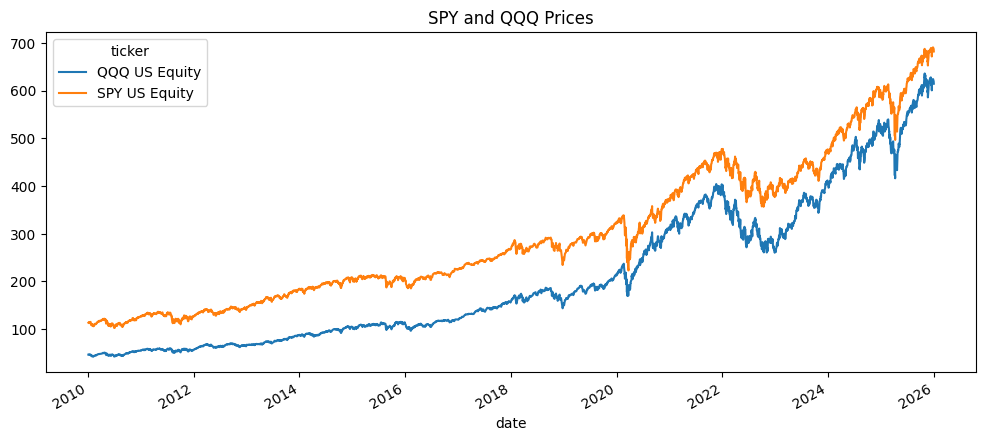

In [145]:
prices.plot(figsize=(12, 5), title="SPY and QQQ Prices")
plt.show()

In [146]:
"""formation_data = prices.iloc[:formation_window].copy()
trading_data = prices.iloc[formation_window:formation_window + trading_window].copy()

formation_data.shape, trading_data.shape"""

'formation_data = prices.iloc[:formation_window].copy()\ntrading_data = prices.iloc[formation_window:formation_window + trading_window].copy()\n\nformation_data.shape, trading_data.shape'

In [148]:
"""x = formation_data["QQQ US Equity"].values
y = formation_data["SPY US Equity"].values

beta, alpha = np.polyfit(x, y, 1)

beta, alpha"""

'x = formation_data["QQQ US Equity"].values\ny = formation_data["SPY US Equity"].values\n\nbeta, alpha = np.polyfit(x, y, 1)\n\nbeta, alpha'

In [149]:
"""formation_spread = formation_data["SPY US Equity"] - (alpha + beta * formation_data["QQQ US Equity"])
trading_spread = trading_data["SPY US Equity"] - (alpha + beta * trading_data["QQQ US Equity"])

formation_spread.head(), trading_spread.head()"""

'formation_spread = formation_data["SPY US Equity"] - (alpha + beta * formation_data["QQQ US Equity"])\ntrading_spread = trading_data["SPY US Equity"] - (alpha + beta * trading_data["QQQ US Equity"])\n\nformation_spread.head(), trading_spread.head()'

In [150]:
"""spread_mean = formation_spread.mean()
spread_std = formation_spread.std()

trading_z = (trading_spread - spread_mean) / spread_std
trading_z.head()"""

'spread_mean = formation_spread.mean()\nspread_std = formation_spread.std()\n\ntrading_z = (trading_spread - spread_mean) / spread_std\ntrading_z.head()'

In [152]:
"""plt.figure(figsize=(12, 5))
plt.plot(trading_z.index, trading_z.values)
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0.5, linestyle="--")
plt.axhline(-0.5, linestyle="--")
plt.axhline(0)
plt.title("Trading Window Z-Score")
plt.show()"""

'plt.figure(figsize=(12, 5))\nplt.plot(trading_z.index, trading_z.values)\nplt.axhline(2, linestyle="--")\nplt.axhline(-2, linestyle="--")\nplt.axhline(0.5, linestyle="--")\nplt.axhline(-0.5, linestyle="--")\nplt.axhline(0)\nplt.title("Trading Window Z-Score")\nplt.show()'

In [154]:
"""position = []
current_pos = 0

for z in trading_z:
    if current_pos == 0:
        if z >= 2:
            current_pos = -1   # short spread
        elif z <= -2:
            current_pos = 1    # long spread
    else:
        if abs(z) <= 0.5:
            current_pos = 0
    
    position.append(current_pos)

trading_results = trading_data.copy()
trading_results["spread"] = trading_spread
trading_results["zscore"] = trading_z
trading_results["position"] = position

trading_results.head(15)"""

'position = []\ncurrent_pos = 0\n\nfor z in trading_z:\n    if current_pos == 0:\n        if z >= 2:\n            current_pos = -1   # short spread\n        elif z <= -2:\n            current_pos = 1    # long spread\n    else:\n        if abs(z) <= 0.5:\n            current_pos = 0\n\n    position.append(current_pos)\n\ntrading_results = trading_data.copy()\ntrading_results["spread"] = trading_spread\ntrading_results["zscore"] = trading_z\ntrading_results["position"] = position\n\ntrading_results.head(15)'

In [155]:
"""trading_results["spread_change"] = trading_results["spread"].diff()
trading_results["strategy_pnl"] = trading_results["position"].shift(1) * trading_results["spread_change"]
trading_results["strategy_pnl"] = trading_results["strategy_pnl"].fillna(0)

trading_results[["spread", "zscore", "position", "spread_change", "strategy_pnl"]].head(15)"""

'trading_results["spread_change"] = trading_results["spread"].diff()\ntrading_results["strategy_pnl"] = trading_results["position"].shift(1) * trading_results["spread_change"]\ntrading_results["strategy_pnl"] = trading_results["strategy_pnl"].fillna(0)\n\ntrading_results[["spread", "zscore", "position", "spread_change", "strategy_pnl"]].head(15)'

In [156]:
"""trading_results["equity_curve"] = trading_results["strategy_pnl"].cumsum()

trading_results["equity_curve"].plot(figsize=(12, 5), title="Simple Equity Curve: SPY-QQQ")
plt.show()"""

'trading_results["equity_curve"] = trading_results["strategy_pnl"].cumsum()\n\ntrading_results["equity_curve"].plot(figsize=(12, 5), title="Simple Equity Curve: SPY-QQQ")\nplt.show()'

In [157]:
"""daily_pnl = trading_results["strategy_pnl"]

mean_daily = daily_pnl.mean()
std_daily = daily_pnl.std()

sharpe = np.nan
if std_daily != 0:
    sharpe = (mean_daily / std_daily) * np.sqrt(252)

cum = trading_results["equity_curve"]
running_max = cum.cummax()
drawdown = cum - running_max
max_drawdown = drawdown.min()

turnover = trading_results["position"].diff().abs().fillna(0).sum()

print("Alpha:", alpha)
print("Beta:", beta)
print("OOS Sharpe:", sharpe)
print("Max Drawdown:", max_drawdown)
print("Turnover:", turnover)"""

'daily_pnl = trading_results["strategy_pnl"]\n\nmean_daily = daily_pnl.mean()\nstd_daily = daily_pnl.std()\n\nsharpe = np.nan\nif std_daily != 0:\n    sharpe = (mean_daily / std_daily) * np.sqrt(252)\n\ncum = trading_results["equity_curve"]\nrunning_max = cum.cummax()\ndrawdown = cum - running_max\nmax_drawdown = drawdown.min()\n\nturnover = trading_results["position"].diff().abs().fillna(0).sum()\n\nprint("Alpha:", alpha)\nprint("Beta:", beta)\nprint("OOS Sharpe:", sharpe)\nprint("Max Drawdown:", max_drawdown)\nprint("Turnover:", turnover)'

In [158]:
pairs = list(combinations(available_universe, 2))

screen_rows = []

for t1, t2 in pairs:
    try:
        pair_prices = all_mid[[t1, t2]].dropna().copy()

        if len(pair_prices) < BASE_FORMATION_WINDOW:
            continue

        formation_data = pair_prices.iloc[:BASE_FORMATION_WINDOW].copy()

        corr = formation_data[t1].corr(formation_data[t2])
        if pd.isna(corr) or corr < BASE_CORR_THRESHOLD:
            continue

        score, pvalue, _ = coint(formation_data[t2], formation_data[t1])
        if pd.isna(pvalue) or pvalue >= BASE_COINT_PVALUE:
            continue

        x = formation_data[t1].values
        y = formation_data[t2].values
        beta, alpha = np.polyfit(x, y, 1)

        formation_spread = formation_data[t2] - (alpha + beta * formation_data[t1])
        spread_std = formation_spread.std()

        screen_rows.append({
            "pair": f"{t1} | {t2}",
            "ticker_1": t1,
            "ticker_2": t2,
            "corr": corr,
            "coint_pvalue": pvalue,
            "alpha": alpha,
            "beta": beta,
            "formation_spread_std": spread_std,
            "formation_obs": len(formation_data)
        })

    except Exception:
        continue

screen_df = pd.DataFrame(screen_rows).sort_values(
    ["coint_pvalue", "corr"],
    ascending=[True, False]
).reset_index(drop=True)

screen_df.head(20)

,pair,ticker_1,ticker_2,corr,coint_pvalue,alpha,beta,formation_spread_std,formation_obs
0,SPY US Equity | IWD US Equity,SPY US Equity,IWD US Equity,0.914431,3.018402e-15,4.938949,0.475954,1.181372,252
1,XLK US Equity | IWF US Equity,XLK US Equity,IWF US Equity,0.966449,1.026042e-04,-0.284257,4.509209,0.771949,252
2,DIA US Equity | XLK US Equity,DIA US Equity,XLK US Equity,0.976489,1.309288e-03,-3.208667,0.136648,0.138853,252
3,XLI US Equity | XLK US Equity,XLI US Equity,XLK US Equity,0.927218,3.263152e-03,2.286038,0.296476,0.241241,252
4,XLB US Equity | XLI US Equity,XLB US Equity,XLI US Equity,0.883679,3.471471e-03,4.992347,1.554406,0.942972,252
5,IWM US Equity | IWD US Equity,IWM US Equity,IWD US Equity,0.874052,9.424006e-03,24.962443,0.510268,1.427733,252
6,SPY US Equity | XLI US Equity,SPY US Equity,XLI US Equity,0.942911,2.360007e-02,-8.015407,0.338722,0.670915,252
7,XLE US Equity | IWF US Equity,XLE US Equity,IWF US Equity,0.929017,2.636260e-02,13.612165,1.304334,1.119607,252
8,DIA US Equity | IWD US Equity,DIA US Equity,IWD US Equity,0.889440,2.715157e-02,-0.912368,0.564012,1.334054,252
9,QQQ US Equity | XLI US Equity,QQQ US Equity,XLI US Equity,0.956140,2.858745e-02,3.357350,0.570593,0.590067,252


In [159]:
screen_df.to_csv("../data_processed/pair_screening_results.csv", index=False)

In [160]:
def prepare_pair_panel(pair_t1, pair_t2, price_panel, cost_panel):
    panel = pd.concat(
        [
            price_panel[pair_t1].rename("x_price"),
            price_panel[pair_t2].rename("y_price"),
            cost_panel[pair_t1].rename("x_cost"),
            cost_panel[pair_t2].rename("y_cost"),
        ],
        axis=1
    ).dropna().sort_index()

    return panel


def build_signal_positions(zscores, entry_z=2.0, exit_z=0.5, max_holding_days=None, stop_z=None):
    signal_position = []
    current_pos = 0
    days_in_trade = 0

    for z in zscores:
        if current_pos == 0:
            days_in_trade = 0
            if z >= entry_z:
                current_pos = -1
            elif z <= -entry_z:
                current_pos = 1
        else:
            days_in_trade += 1
            exit_now = abs(z) <= exit_z

            if stop_z is not None and abs(z) >= stop_z:
                exit_now = True

            if max_holding_days is not None and days_in_trade >= max_holding_days:
                exit_now = True

            if exit_now:
                current_pos = 0
                days_in_trade = 0

        signal_position.append(current_pos)

    return pd.Series(signal_position, index=zscores.index, dtype=float)


def extract_trade_log(wf_df):
    trade_cols = [
        "trade_id", "entry_date", "exit_date", "side",
        "entry_z", "exit_z", "holding_days",
        "gross_return", "cost_paid", "net_return",
        "forced_window_end_exit", "exit_reason"

    ]

    if wf_df.empty:
        return pd.DataFrame(columns=trade_cols)

    active = wf_df[wf_df["held_position"] != 0].copy()
    if active.empty:
        return pd.DataFrame(columns=trade_cols)

    new_trade_flag = (wf_df["held_position"] != wf_df["held_position"].shift(1)).reindex(active.index).fillna(True)
    active["trade_id"] = new_trade_flag.cumsum()

    entry_dates = active.groupby("trade_id").apply(lambda x: x.index[0])
    exit_dates = active.groupby("trade_id").apply(lambda x: x.index[-1])

    trade_log = active.groupby("trade_id").agg(
        side=("held_position", "first"),
        entry_z=("zscore", "first"),
        exit_z=("zscore", "last"),
        holding_days=("held_position", "size"),
        gross_return=("gross_pair_ret", "sum"),
        cost_paid=("trading_cost", "sum"),
        net_return=("net_pair_ret", "sum"),
        forced_window_end_exit=("forced_window_end_exit", "max"),
    ).reset_index()
    
    trade_log["exit_reason"] = np.where(
    trade_log["forced_window_end_exit"],
    "window_end",
    "signal_exit"
    )

    trade_log["entry_date"] = trade_log["trade_id"].map(entry_dates)
    trade_log["exit_date"] = trade_log["trade_id"].map(exit_dates)

    trade_log = trade_log[
        [
            "trade_id", "entry_date", "exit_date", "side",
            "entry_z", "exit_z", "holding_days",
            "gross_return", "cost_paid", "net_return",
            "forced_window_end_exit", "exit_reason"
        ]
    ].copy()

    return trade_log


def compute_summary_metrics(wf_df, trade_log=None):
    if wf_df.empty:
        return {
        "annual_return": np.nan,
        "annual_vol": np.nan,
        "sharpe": np.nan,
        "max_dd": np.nan,
        "turnover": 0.0,
        "exposure_days": 0,
        "exposure_ratio": 0.0,
        "active_days": 0,
        "active_day_share": 0.0,
        "active_day_mean_return": np.nan,
        "active_day_vol": np.nan,
        "active_day_sharpe": np.nan,
        "n_trades": 0,
        "hit_rate": np.nan,
        "avg_holding_days": np.nan,
        "avg_trade_return": np.nan
}

    r = wf_df["net_pair_ret"].fillna(0)
    active_r = wf_df.loc[wf_df["held_position"] != 0, "net_pair_ret"].copy()
    n = len(r)

    annual_return = np.nan
    if n > 0:
        annual_return = (1 + r).prod() ** (ANNUALIZATION / n) - 1

    annual_vol = r.std() * np.sqrt(ANNUALIZATION) if n > 1 else np.nan

    sharpe = np.nan
    if n > 1 and r.std() != 0 and not np.isnan(r.std()):
        sharpe = (r.mean() / r.std()) * np.sqrt(ANNUALIZATION)

    equity = (1 + r).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min() if len(drawdown) else np.nan

    turnover = wf_df["trade_size"].sum()
    exposure_days = int((wf_df["held_position"] != 0).sum())
    exposure_ratio = exposure_days / len(wf_df) if len(wf_df) else np.nan

    metrics = {
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_dd": max_dd,
        "turnover": turnover,
        "exposure_days": exposure_days,
        "exposure_ratio": exposure_ratio,
        "active_days": len(active_r),
        "active_day_share": len(active_r) / len(wf_df) if len(wf_df) else np.nan,
        "active_day_mean_return": active_r.mean() if len(active_r) > 0 else np.nan,
        "active_day_vol": active_r.std() if len(active_r) > 1 else np.nan,
        "active_day_sharpe": (
            (active_r.mean() / active_r.std()) * np.sqrt(ANNUALIZATION)
            if len(active_r) > 1 and active_r.std() != 0 else np.nan
            ),
        }

    if trade_log is not None and not trade_log.empty:
        metrics["n_trades"] = len(trade_log)
        metrics["hit_rate"] = (trade_log["net_return"] > 0).mean()
        metrics["avg_holding_days"] = trade_log["holding_days"].mean()
        metrics["avg_trade_return"] = trade_log["net_return"].mean()
    else:
        metrics["n_trades"] = 0
        metrics["hit_rate"] = np.nan
        metrics["avg_holding_days"] = np.nan
        metrics["avg_trade_return"] = np.nan

    return metrics

In [161]:
"""pair_t1 = "IEF US Equity"
pair_t2 = "SHY US Equity"

pair_prices = all_prices[[pair_t1, pair_t2]].dropna().copy()

formation_window = 252
trading_window = 63

formation_data = pair_prices.iloc[:formation_window].copy()
trading_data = pair_prices.iloc[formation_window:formation_window + trading_window].copy()

x = formation_data[pair_t1].values
y = formation_data[pair_t2].values

beta, alpha = np.polyfit(x, y, 1)

formation_spread = formation_data[pair_t2] - (alpha + beta * formation_data[pair_t1])
trading_spread = trading_data[pair_t2] - (alpha + beta * trading_data[pair_t1])

spread_mean = formation_spread.mean()
spread_std = formation_spread.std()

trading_z = (trading_spread - spread_mean) / spread_std

position = []
current_pos = 0

for z in trading_z:
    if current_pos == 0:
        if z >= 2:
            current_pos = -1
        elif z <= -2:
            current_pos = 1
    else:
        if abs(z) <= 0.5:
            current_pos = 0
    position.append(current_pos)

pair_results = trading_data.copy()
pair_results["spread"] = trading_spread
pair_results["zscore"] = trading_z
pair_results["position"] = position
pair_results["spread_change"] = pair_results["spread"].diff()
pair_results["strategy_pnl"] = pair_results["position"].shift(1) * pair_results["spread_change"]
pair_results["strategy_pnl"] = pair_results["strategy_pnl"].fillna(0)
pair_results["equity_curve"] = pair_results["strategy_pnl"].cumsum()

pair_results.head(15)"""

'pair_t1 = "IEF US Equity"\npair_t2 = "SHY US Equity"\n\npair_prices = all_prices[[pair_t1, pair_t2]].dropna().copy()\n\nformation_window = 252\ntrading_window = 63\n\nformation_data = pair_prices.iloc[:formation_window].copy()\ntrading_data = pair_prices.iloc[formation_window:formation_window + trading_window].copy()\n\nx = formation_data[pair_t1].values\ny = formation_data[pair_t2].values\n\nbeta, alpha = np.polyfit(x, y, 1)\n\nformation_spread = formation_data[pair_t2] - (alpha + beta * formation_data[pair_t1])\ntrading_spread = trading_data[pair_t2] - (alpha + beta * trading_data[pair_t1])\n\nspread_mean = formation_spread.mean()\nspread_std = formation_spread.std()\n\ntrading_z = (trading_spread - spread_mean) / spread_std\n\nposition = []\ncurrent_pos = 0\n\nfor z in trading_z:\n    if current_pos == 0:\n        if z >= 2:\n            current_pos = -1\n        elif z <= -2:\n            current_pos = 1\n    else:\n        if abs(z) <= 0.5:\n            current_pos = 0\n    posit

In [162]:
"""plt.figure(figsize=(12, 5))
plt.plot(pair_results.index, pair_results["equity_curve"])
plt.title("Equity Curve: IEF vs SHY")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.show()"""

'plt.figure(figsize=(12, 5))\nplt.plot(pair_results.index, pair_results["equity_curve"])\nplt.title("Equity Curve: IEF vs SHY")\nplt.xlabel("Date")\nplt.ylabel("Cumulative PnL")\nplt.grid(True)\nplt.show()'

In [163]:
"""plt.figure(figsize=(12, 5))
plt.plot(pair_results.index, pair_results["zscore"])
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0.5, linestyle="--")
plt.axhline(-0.5, linestyle="--")
plt.axhline(0)
plt.title("Z-Score: IEF vs SHY")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.show()"""

'plt.figure(figsize=(12, 5))\nplt.plot(pair_results.index, pair_results["zscore"])\nplt.axhline(2, linestyle="--")\nplt.axhline(-2, linestyle="--")\nplt.axhline(0.5, linestyle="--")\nplt.axhline(-0.5, linestyle="--")\nplt.axhline(0)\nplt.title("Z-Score: IEF vs SHY")\nplt.xlabel("Date")\nplt.ylabel("Z-Score")\nplt.grid(True)\nplt.show()'

In [164]:
"""pair_results[["spread", "zscore", "position", "strategy_pnl", "equity_curve"]].head(30)"""

'pair_results[["spread", "zscore", "position", "strategy_pnl", "equity_curve"]].head(30)'

In [165]:
"""plt.figure(figsize=(12, 5))
plt.plot(pair_results.index, pair_results["equity_curve"])
plt.title("Equity Curve: IEF vs SHY")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.tight_layout()
plt.savefig("../data_processed/ief_shy_equity_curve.png", dpi=300, bbox_inches="tight")
plt.show()"""

'plt.figure(figsize=(12, 5))\nplt.plot(pair_results.index, pair_results["equity_curve"])\nplt.title("Equity Curve: IEF vs SHY")\nplt.xlabel("Date")\nplt.ylabel("Cumulative PnL")\nplt.grid(True)\nplt.tight_layout()\nplt.savefig("../data_processed/ief_shy_equity_curve.png", dpi=300, bbox_inches="tight")\nplt.show()'

In [166]:
"""pair_results["position_change"] = pair_results["position"].diff().abs().fillna(0)

cost_bps = 5
cost_rate = cost_bps / 10000  # 5 bps = 0.0005

# простая fixed-cost модель:
pair_results["trading_cost"] = pair_results["position_change"] * cost_rate

pair_results["strategy_pnl_after_cost"] = pair_results["strategy_pnl"] - pair_results["trading_cost"]
pair_results["equity_curve_after_cost"] = pair_results["strategy_pnl_after_cost"].cumsum()

pair_results[["position", "position_change", "strategy_pnl", "trading_cost", "strategy_pnl_after_cost"]].head(20)"""

'pair_results["position_change"] = pair_results["position"].diff().abs().fillna(0)\n\ncost_bps = 5\ncost_rate = cost_bps / 10000  # 5 bps = 0.0005\n\n# простая fixed-cost модель:\npair_results["trading_cost"] = pair_results["position_change"] * cost_rate\n\npair_results["strategy_pnl_after_cost"] = pair_results["strategy_pnl"] - pair_results["trading_cost"]\npair_results["equity_curve_after_cost"] = pair_results["strategy_pnl_after_cost"].cumsum()\n\npair_results[["position", "position_change", "strategy_pnl", "trading_cost", "strategy_pnl_after_cost"]].head(20)'

In [167]:
"""plt.figure(figsize=(12, 5))
plt.plot(pair_results.index, pair_results["equity_curve"], label="Before costs")
plt.plot(pair_results.index, pair_results["equity_curve_after_cost"], label="After 5 bps costs")
plt.title("IEF vs SHY: Equity Curve Before and After Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True)
plt.show()"""

'plt.figure(figsize=(12, 5))\nplt.plot(pair_results.index, pair_results["equity_curve"], label="Before costs")\nplt.plot(pair_results.index, pair_results["equity_curve_after_cost"], label="After 5 bps costs")\nplt.title("IEF vs SHY: Equity Curve Before and After Costs")\nplt.xlabel("Date")\nplt.ylabel("Cumulative PnL")\nplt.legend()\nplt.grid(True)\nplt.show()'

In [168]:
"""daily_pnl_after_cost = pair_results["strategy_pnl_after_cost"]

mean_daily_after_cost = daily_pnl_after_cost.mean()
std_daily_after_cost = daily_pnl_after_cost.std()

sharpe_after_cost = np.nan
if std_daily_after_cost != 0 and not np.isnan(std_daily_after_cost):
    sharpe_after_cost = (mean_daily_after_cost / std_daily_after_cost) * np.sqrt(252)

cum_after_cost = pair_results["equity_curve_after_cost"]
running_max_after_cost = cum_after_cost.cummax()
drawdown_after_cost = cum_after_cost - running_max_after_cost
max_drawdown_after_cost = drawdown_after_cost.min()

print("Sharpe before costs:", results_df.loc[results_df["pair"] == "IEF US Equity | SHY US Equity", "sharpe"].values)
print("Sharpe after costs:", sharpe_after_cost)
print("Max drawdown after costs:", max_drawdown_after_cost)"""

'daily_pnl_after_cost = pair_results["strategy_pnl_after_cost"]\n\nmean_daily_after_cost = daily_pnl_after_cost.mean()\nstd_daily_after_cost = daily_pnl_after_cost.std()\n\nsharpe_after_cost = np.nan\nif std_daily_after_cost != 0 and not np.isnan(std_daily_after_cost):\n    sharpe_after_cost = (mean_daily_after_cost / std_daily_after_cost) * np.sqrt(252)\n\ncum_after_cost = pair_results["equity_curve_after_cost"]\nrunning_max_after_cost = cum_after_cost.cummax()\ndrawdown_after_cost = cum_after_cost - running_max_after_cost\nmax_drawdown_after_cost = drawdown_after_cost.min()\n\nprint("Sharpe before costs:", results_df.loc[results_df["pair"] == "IEF US Equity | SHY US Equity", "sharpe"].values)\nprint("Sharpe after costs:", sharpe_after_cost)\nprint("Max drawdown after costs:", max_drawdown_after_cost)'

In [169]:
"""pair_t1 = "IEF US Equity"
pair_t2 = "SHY US Equity"

pair_prices = all_prices[[pair_t1, pair_t2]].dropna().copy()

formation_window = 252
trading_window = 63
cost_bps = 5
cost_rate = cost_bps / 10000

walkforward_results = []

start = 0

while start + formation_window + trading_window <= len(pair_prices):
    formation_data = pair_prices.iloc[start:start + formation_window].copy()
    trading_data = pair_prices.iloc[start + formation_window:start + formation_window + trading_window].copy()

    x = formation_data[pair_t1].values
    y = formation_data[pair_t2].values

    beta, alpha = np.polyfit(x, y, 1)

    formation_spread = formation_data[pair_t2] - (alpha + beta * formation_data[pair_t1])
    trading_spread = trading_data[pair_t2] - (alpha + beta * trading_data[pair_t1])

    spread_mean = formation_spread.mean()
    spread_std = formation_spread.std()

    if spread_std == 0 or np.isnan(spread_std):
        start += trading_window
        continue

    trading_z = (trading_spread - spread_mean) / spread_std

    position = []
    current_pos = 0

    for z in trading_z:
        if current_pos == 0:
            if z >= 2:
                current_pos = -1
            elif z <= -2:
                current_pos = 1
        else:
            if abs(z) <= 0.5:
                current_pos = 0
        position.append(current_pos)

    temp = trading_data.copy()
    temp["spread"] = trading_spread
    temp["zscore"] = trading_z
    temp["position"] = position
    temp["spread_change"] = temp["spread"].diff()
    temp["strategy_pnl"] = temp["position"].shift(1) * temp["spread_change"]
    temp["strategy_pnl"] = temp["strategy_pnl"].fillna(0)

    temp["position_change"] = temp["position"].diff().abs().fillna(0)
    temp["trading_cost"] = temp["position_change"] * cost_rate
    temp["strategy_pnl_after_cost"] = temp["strategy_pnl"] - temp["trading_cost"]

    temp["window_start"] = formation_data.index[0]
    temp["window_end"] = trading_data.index[-1]

    walkforward_results.append(temp)

    start += trading_window

wf_df = pd.concat(walkforward_results).sort_index()
wf_df.head()"""

'pair_t1 = "IEF US Equity"\npair_t2 = "SHY US Equity"\n\npair_prices = all_prices[[pair_t1, pair_t2]].dropna().copy()\n\nformation_window = 252\ntrading_window = 63\ncost_bps = 5\ncost_rate = cost_bps / 10000\n\nwalkforward_results = []\n\nstart = 0\n\nwhile start + formation_window + trading_window <= len(pair_prices):\n    formation_data = pair_prices.iloc[start:start + formation_window].copy()\n    trading_data = pair_prices.iloc[start + formation_window:start + formation_window + trading_window].copy()\n\n    x = formation_data[pair_t1].values\n    y = formation_data[pair_t2].values\n\n    beta, alpha = np.polyfit(x, y, 1)\n\n    formation_spread = formation_data[pair_t2] - (alpha + beta * formation_data[pair_t1])\n    trading_spread = trading_data[pair_t2] - (alpha + beta * trading_data[pair_t1])\n\n    spread_mean = formation_spread.mean()\n    spread_std = formation_spread.std()\n\n    if spread_std == 0 or np.isnan(spread_std):\n        start += trading_window\n        continue

In [170]:
"""wf_df["equity_curve_after_cost"] = wf_df["strategy_pnl_after_cost"].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(wf_df.index, wf_df["equity_curve_after_cost"])
plt.title("Walk-Forward Equity Curve After Costs: IEF vs SHY")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.show()"""

'wf_df["equity_curve_after_cost"] = wf_df["strategy_pnl_after_cost"].cumsum()\n\nplt.figure(figsize=(12, 5))\nplt.plot(wf_df.index, wf_df["equity_curve_after_cost"])\nplt.title("Walk-Forward Equity Curve After Costs: IEF vs SHY")\nplt.xlabel("Date")\nplt.ylabel("Cumulative PnL")\nplt.grid(True)\nplt.show()'

In [171]:
"""daily_pnl_wf = wf_df["strategy_pnl_after_cost"]

mean_daily_wf = daily_pnl_wf.mean()
std_daily_wf = daily_pnl_wf.std()

wf_sharpe = np.nan
if std_daily_wf != 0 and not np.isnan(std_daily_wf):
    wf_sharpe = (mean_daily_wf / std_daily_wf) * np.sqrt(252)

cum_wf = wf_df["equity_curve_after_cost"]
running_max_wf = cum_wf.cummax()
drawdown_wf = cum_wf - running_max_wf
wf_max_dd = drawdown_wf.min()

wf_turnover = wf_df["position_change"].sum()

print("Walk-forward Sharpe after costs:", wf_sharpe)
print("Walk-forward Max Drawdown:", wf_max_dd)
print("Walk-forward Turnover:", wf_turnover)
print("Number of OOS observations:", len(wf_df))"""

'daily_pnl_wf = wf_df["strategy_pnl_after_cost"]\n\nmean_daily_wf = daily_pnl_wf.mean()\nstd_daily_wf = daily_pnl_wf.std()\n\nwf_sharpe = np.nan\nif std_daily_wf != 0 and not np.isnan(std_daily_wf):\n    wf_sharpe = (mean_daily_wf / std_daily_wf) * np.sqrt(252)\n\ncum_wf = wf_df["equity_curve_after_cost"]\nrunning_max_wf = cum_wf.cummax()\ndrawdown_wf = cum_wf - running_max_wf\nwf_max_dd = drawdown_wf.min()\n\nwf_turnover = wf_df["position_change"].sum()\n\nprint("Walk-forward Sharpe after costs:", wf_sharpe)\nprint("Walk-forward Max Drawdown:", wf_max_dd)\nprint("Walk-forward Turnover:", wf_turnover)\nprint("Number of OOS observations:", len(wf_df))'

In [172]:
"""baseline_summary = {
    "pair": "IEF US Equity | SHY US Equity",
    "formation_window": 252,
    "trading_window": 63,
    "entry_z": 2.0,
    "exit_z": 0.5,
    "cost_bps": 5,
    "wf_sharpe_after_cost": wf_sharpe,
    "wf_max_drawdown": wf_max_dd,
    "wf_turnover": wf_turnover,
    "oos_observations": len(wf_df)
}

baseline_summary"""

'baseline_summary = {\n    "pair": "IEF US Equity | SHY US Equity",\n    "formation_window": 252,\n    "trading_window": 63,\n    "entry_z": 2.0,\n    "exit_z": 0.5,\n    "cost_bps": 5,\n    "wf_sharpe_after_cost": wf_sharpe,\n    "wf_max_drawdown": wf_max_dd,\n    "wf_turnover": wf_turnover,\n    "oos_observations": len(wf_df)\n}\n\nbaseline_summary'

In [173]:
"""baseline_summary_df = pd.DataFrame([baseline_summary])
baseline_summary_df"""

'baseline_summary_df = pd.DataFrame([baseline_summary])\nbaseline_summary_df'

In [174]:
"""baseline_summary_df.to_csv("../data_processed/baseline_summary.csv", index=False)"""

'baseline_summary_df.to_csv("../data_processed/baseline_summary.csv", index=False)'

In [175]:
spy_prices = all_mid[["SPY US Equity"]].dropna().copy()
spy_prices = spy_prices.loc[
    baseline_run["wf_df"].index.min():baseline_run["wf_df"].index.max()
].copy()

spy_prices["spy_return"] = spy_prices["SPY US Equity"].pct_change().fillna(0)
spy_prices["spy_equity"] = (1 + spy_prices["spy_return"]).cumprod()

spy_prices.head()

ticker,SPY US Equity,spy_return,spy_equity
date,,,
2011-01-03,126.875,0.000000,1.000000
2011-01-04,126.915,0.000315,1.000315
2011-01-05,127.545,0.004964,1.005281
2011-01-06,127.390,-0.001215,1.004059
2011-01-07,127.120,-0.002119,1.001931


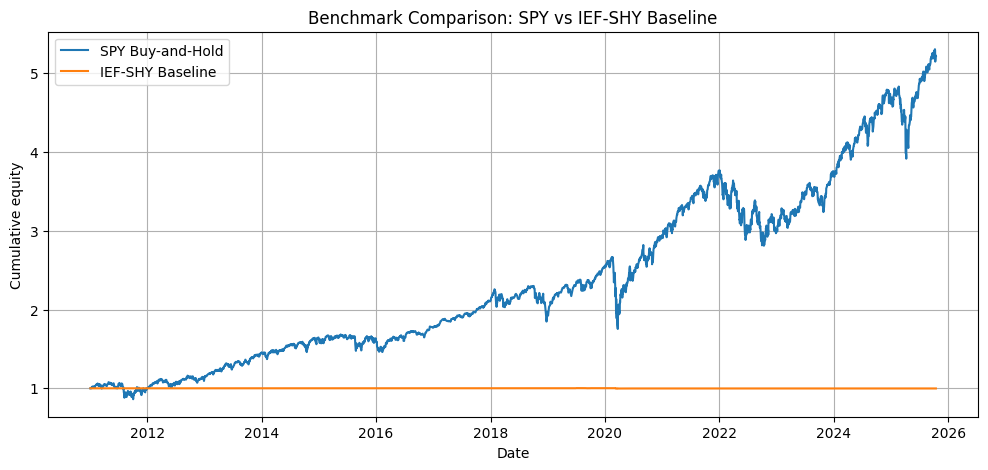

In [176]:
plt.figure(figsize=(12, 5))
plt.plot(spy_prices.index, spy_prices["spy_equity"], label="SPY Buy-and-Hold")
plt.plot(baseline_run["wf_df"].index, baseline_run["wf_df"]["net_equity_curve"], label="IEF-SHY Baseline")
plt.title("Benchmark Comparison: SPY vs IEF-SHY Baseline")
plt.xlabel("Date")
plt.ylabel("Cumulative equity")
plt.legend()
plt.grid(True)
plt.show()

In [177]:
spy_daily = spy_prices["spy_return"].fillna(0)

spy_ann_return = (1 + spy_daily).prod() ** (ANNUALIZATION / len(spy_daily)) - 1 if len(spy_daily) > 0 else np.nan
spy_ann_vol = spy_daily.std() * np.sqrt(ANNUALIZATION) if len(spy_daily) > 1 else np.nan
spy_sharpe = (spy_daily.mean() / spy_daily.std()) * np.sqrt(ANNUALIZATION) if len(spy_daily) > 1 and spy_daily.std() != 0 else np.nan

spy_drawdown = spy_prices["spy_equity"] / spy_prices["spy_equity"].cummax() - 1
spy_max_dd = spy_drawdown.min()

benchmark_summary = pd.DataFrame([{
    "benchmark": "SPY Buy-and-Hold",
    "annual_return": spy_ann_return,
    "annual_vol": spy_ann_vol,
    "sharpe": spy_sharpe,
    "max_dd": spy_max_dd,
    "oos_obs": len(spy_prices)
}])

benchmark_summary

,benchmark,annual_return,annual_vol,sharpe,max_dd,oos_obs
0,SPY Buy-and-Hold,0.130082,0.180474,0.768274,-0.342369,3405


In [178]:
def run_walkforward_pair(
    pair_panel,
    pair_t1,
    pair_t2,
    formation_window=BASE_FORMATION_WINDOW,
    trading_window=BASE_TRADING_WINDOW,
    entry_z=BASE_ENTRY_Z,
    exit_z=BASE_EXIT_Z,
    cost_model=BASE_COST_MODEL,
    fixed_bps=BASE_FIXED_BPS,
    corr_threshold=BASE_CORR_THRESHOLD,
    coint_pvalue_threshold=BASE_COINT_PVALUE,
    max_holding_days=None,
    stop_z=None,
    label=None
):
    walkforward_results = []
    window_diagnostics = []

    start = 0
    window_id = 0

    while start + formation_window + trading_window <= len(pair_panel):
        formation_data = pair_panel.iloc[start:start + formation_window].copy()
        trading_data = pair_panel.iloc[start + formation_window:start + formation_window + trading_window].copy()

        corr = formation_data["x_price"].corr(formation_data["y_price"])
        pvalue = np.nan
        alpha = np.nan
        beta = np.nan
        spread_mean = np.nan
        spread_std = np.nan
        tradable = True
        skip_reason = None

        if pd.isna(corr) or corr < corr_threshold:
            tradable = False
            skip_reason = "corr_fail"
        else:
            try:
                _, pvalue, _ = coint(formation_data["y_price"], formation_data["x_price"])
            except Exception:
                pvalue = np.nan

            if pd.isna(pvalue) or pvalue >= coint_pvalue_threshold:
                tradable = False
                skip_reason = "coint_fail"

        if tradable:
            x = formation_data["x_price"].values
            y = formation_data["y_price"].values
            beta, alpha = np.polyfit(x, y, 1)

            formation_spread = formation_data["y_price"] - (alpha + beta * formation_data["x_price"])
            trading_spread = trading_data["y_price"] - (alpha + beta * trading_data["x_price"])

            spread_mean = formation_spread.mean()
            spread_std = formation_spread.std()

            if spread_std == 0 or np.isnan(spread_std):
                tradable = False
                skip_reason = "spread_std_fail"

        temp = trading_data.copy()
        temp["pair"] = f"{pair_t1} | {pair_t2}"
        temp["window_id"] = window_id
        temp["formation_start"] = formation_data.index[0]
        temp["formation_end"] = formation_data.index[-1]
        temp["trading_start"] = trading_data.index[0]
        temp["trading_end"] = trading_data.index[-1]
        temp["corr"] = corr
        temp["coint_pvalue"] = pvalue
        temp["alpha"] = alpha
        temp["beta"] = beta
        temp["tradable"] = tradable
        temp["skip_reason"] = skip_reason

        temp["x_return"] = temp["x_price"].pct_change().fillna(0)
        temp["y_return"] = temp["y_price"].pct_change().fillna(0)

        if tradable:
            temp["spread"] = trading_spread
            temp["zscore"] = (trading_spread - spread_mean) / spread_std

            temp["signal_position"] = build_signal_positions(
                temp["zscore"],
                entry_z=entry_z,
                exit_z=exit_z,
                max_holding_days=max_holding_days,
                stop_z=stop_z
            )

            temp["held_position"] = temp["signal_position"].shift(1).fillna(0)
            temp["trade_size"] = temp["held_position"].diff().abs().fillna(temp["held_position"].abs())
            temp["forced_window_end_exit"] = False
            if len(temp) > 0 and temp["held_position"].iloc[-1] != 0:
                temp.iloc[-1, temp.columns.get_loc("forced_window_end_exit")] = True

            temp["gross_pair_ret"] = temp["held_position"] * (
                (temp["y_return"] - beta * temp["x_return"]) / (1 + abs(beta))
            )

            w_y = 1 / (1 + abs(beta))
            w_x = abs(beta) / (1 + abs(beta))

            if cost_model == "bid_ask":
                temp["pair_cost_rate"] = (w_y * temp["y_cost"]) + (w_x * temp["x_cost"])
            elif cost_model == "fixed_bps":
                temp["pair_cost_rate"] = fixed_bps / 10000
            else:
                raise ValueError("cost_model must be either 'bid_ask' or 'fixed_bps'")

            temp["trading_cost"] = temp["trade_size"] * temp["pair_cost_rate"]
            temp["net_pair_ret"] = temp["gross_pair_ret"] - temp["trading_cost"]

        else:
            temp["spread"] = np.nan
            temp["zscore"] = np.nan
            temp["signal_position"] = 0.0
            temp["held_position"] = 0.0
            temp["trade_size"] = 0.0
            temp["gross_pair_ret"] = 0.0
            temp["pair_cost_rate"] = 0.0
            temp["trading_cost"] = 0.0
            temp["net_pair_ret"] = 0.0

        walkforward_results.append(temp)

        window_diagnostics.append({
            "window_id": window_id,
            "pair": f"{pair_t1} | {pair_t2}",
            "formation_start": formation_data.index[0],
            "formation_end": formation_data.index[-1],
            "trading_start": trading_data.index[0],
            "trading_end": trading_data.index[-1],
            "corr": corr,
            "coint_pvalue": pvalue,
            "alpha": alpha,
            "beta": beta,
            "spread_std": spread_std,
            "tradable": tradable,
            "skip_reason": skip_reason
        })

        start += trading_window
        window_id += 1

    if not walkforward_results:
        empty_df = pd.DataFrame()
        empty_trade_log = pd.DataFrame()
        empty_summary = {
            "pair": f"{pair_t1} | {pair_t2}",
            "label": label,
            "formation_window": formation_window,
            "trading_window": trading_window,
            "entry_z": entry_z,
            "exit_z": exit_z,
            "cost_model": cost_model,
            "fixed_bps": fixed_bps
        }
        return {
            "wf_df": empty_df,
            "trade_log": empty_trade_log,
            "summary": empty_summary,
            "window_diagnostics": pd.DataFrame(window_diagnostics)
        }

    wf_df_local = pd.concat(walkforward_results).sort_index()
    wf_df_local["gross_equity_curve"] = (1 + wf_df_local["gross_pair_ret"]).cumprod()
    wf_df_local["net_equity_curve"] = (1 + wf_df_local["net_pair_ret"]).cumprod()

    trade_log = extract_trade_log(wf_df_local)
    summary_metrics = compute_summary_metrics(wf_df_local, trade_log)

    summary = {
        "pair": f"{pair_t1} | {pair_t2}",
        "label": label,
        "formation_window": formation_window,
        "trading_window": trading_window,
        "entry_z": entry_z,
        "exit_z": exit_z,
        "cost_model": cost_model,
        "fixed_bps": fixed_bps,
        "oos_obs": len(wf_df_local),
        "tradable_window_share": pd.DataFrame(window_diagnostics)["tradable"].mean()
    }
    summary.update(summary_metrics)

    return {
        "wf_df": wf_df_local,
        "trade_log": trade_log,
        "summary": summary,
        "window_diagnostics": pd.DataFrame(window_diagnostics)
    }

In [179]:
pair_t1 = "IEF US Equity"
pair_t2 = "SHY US Equity"

pair_panel = prepare_pair_panel(
    pair_t1,
    pair_t2,
    price_panel=all_mid,
    cost_panel=all_half_spread
)

baseline_run = run_walkforward_pair(
    pair_panel=pair_panel,
    pair_t1=pair_t1,
    pair_t2=pair_t2,
    formation_window=252,
    trading_window=63,
    entry_z=2.0,
    exit_z=0.5,
    cost_model="bid_ask",
    fixed_bps=5,
    label="baseline_bid_ask"
)

variation_1 = run_walkforward_pair(
    pair_panel=pair_panel,
    pair_t1=pair_t1,
    pair_t2=pair_t2,
    formation_window=252,
    trading_window=63,
    entry_z=1.5,
    exit_z=0.5,
    cost_model="bid_ask",
    fixed_bps=5,
    label="variation_entry_1_5"
)

variation_2 = run_walkforward_pair(
    pair_panel=pair_panel,
    pair_t1=pair_t1,
    pair_t2=pair_t2,
    formation_window=126,
    trading_window=63,
    entry_z=2.0,
    exit_z=0.5,
    cost_model="bid_ask",
    fixed_bps=5,
    label="variation_formation_126"
)

variation_3 = run_walkforward_pair(
    pair_panel=pair_panel,
    pair_t1=pair_t1,
    pair_t2=pair_t2,
    formation_window=252,
    trading_window=63,
    entry_z=2.0,
    exit_z=0.5,
    cost_model="fixed_bps",
    fixed_bps=5,
    label="variation_fixed_5bps"
)

In [180]:
comparison_df = pd.DataFrame([
    baseline_run["summary"],
    variation_1["summary"],
    variation_2["summary"],
    variation_3["summary"]
])

comparison_df = comparison_df[
    [
        "label", "pair",
        "formation_window", "trading_window",
        "entry_z", "exit_z",
        "cost_model", "fixed_bps",
        "annual_return", "annual_vol", "sharpe", "max_dd",
        "turnover", "n_trades", "hit_rate", "avg_holding_days",
        "exposure_ratio", "tradable_window_share", "oos_obs"
    ]
].copy()

comparison_df

,label,pair,formation_window,trading_window,entry_z,exit_z,cost_model,fixed_bps,annual_return,annual_vol,sharpe,max_dd,turnover,n_trades,hit_rate,avg_holding_days,exposure_ratio,tradable_window_share,oos_obs
0,baseline_bid_ask,IEF US Equity | SHY US Equity,252,63,2.0,0.5,bid_ask,5,-0.000129,0.001609,-0.079678,-0.006835,7.0,5,0.400000,21.800000,0.029325,0.084746,3717
1,variation_entry_1_5,IEF US Equity | SHY US Equity,252,63,1.5,0.5,bid_ask,5,-0.000045,0.001867,-0.023386,-0.008464,16.0,10,0.700000,16.800000,0.045198,0.084746,3717
2,variation_formation_126,IEF US Equity | SHY US Equity,126,63,2.0,0.5,bid_ask,5,-0.000791,0.002615,-0.301293,-0.016565,22.0,15,0.533333,21.933333,0.085610,0.163934,3843
3,variation_fixed_5bps,IEF US Equity | SHY US Equity,252,63,2.0,0.5,fixed_bps,5,-0.000336,0.001658,-0.202009,-0.008156,7.0,5,0.400000,21.800000,0.029325,0.084746,3717


In [181]:
comparison_df.to_csv("../data_processed/variation_summary_ief_shy.csv", index=False)

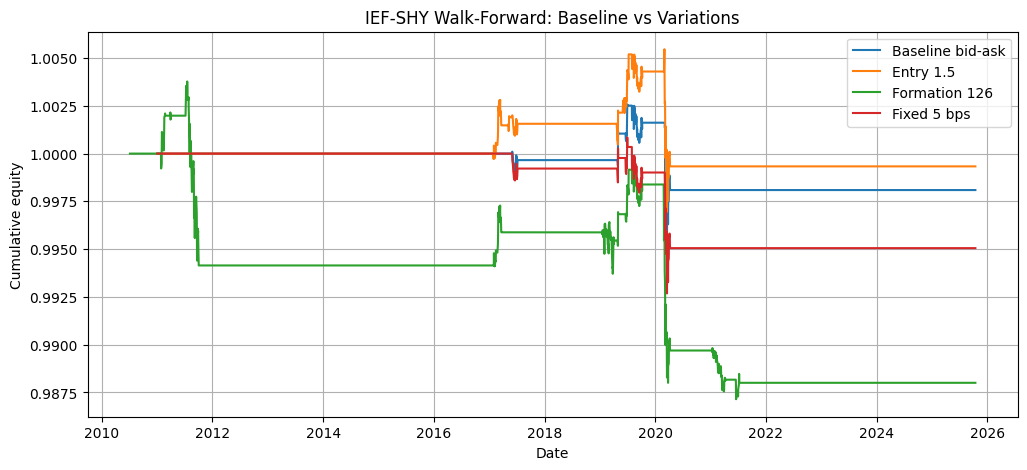

In [182]:
plt.figure(figsize=(12, 5))
plt.plot(baseline_run["wf_df"].index, baseline_run["wf_df"]["net_equity_curve"], label="Baseline bid-ask")
plt.plot(variation_1["wf_df"].index, variation_1["wf_df"]["net_equity_curve"], label="Entry 1.5")
plt.plot(variation_2["wf_df"].index, variation_2["wf_df"]["net_equity_curve"], label="Formation 126")
plt.plot(variation_3["wf_df"].index, variation_3["wf_df"]["net_equity_curve"], label="Fixed 5 bps")
plt.title("IEF-SHY Walk-Forward: Baseline vs Variations")
plt.xlabel("Date")
plt.ylabel("Cumulative equity")
plt.legend()
plt.grid(True)
plt.show()

In [183]:
baseline_run["wf_df"].to_csv("../data_processed/baseline_daily_results_ief_shy.csv", index=True)
baseline_run["trade_log"].to_csv("../data_processed/baseline_trade_log_ief_shy.csv", index=False)
baseline_run["window_diagnostics"].to_csv("../data_processed/window_diagnostics_ief_shy.csv", index=False)

In [184]:
diag = baseline_run["window_diagnostics"].copy()
diag["status"] = np.where(diag["tradable"], "passed", diag["skip_reason"])
diag["status"].value_counts(dropna=False)

status
corr_fail     27
coint_fail    27
passed         5
Name: count, dtype: int64

In [185]:
diag.groupby("status").size().to_frame("n_windows")

,n_windows
status,
coint_fail,27
corr_fail,27
passed,5


In [186]:
passed_windows = diag[diag["tradable"]].copy()
passed_windows[[
    "window_id", "formation_start", "formation_end",
    "trading_start", "trading_end",
    "corr", "coint_pvalue"
]]

,window_id,formation_start,formation_end,trading_start,trading_end,corr,coint_pvalue
24,24,2016-01-07,2017-01-05,2017-01-06,2017-04-06,0.971324,0.004374
25,25,2016-04-08,2017-04-06,2017-04-07,2017-07-07,0.983127,0.009193
33,33,2018-04-10,2019-04-09,2019-04-10,2019-07-10,0.972959,0.006647
34,34,2018-07-10,2019-07-10,2019-07-11,2019-10-08,0.993055,0.000940
36,36,2019-01-09,2020-01-08,2020-01-09,2020-04-08,0.982953,0.024839


In [187]:
baseline_run["trade_log"]

,trade_id,entry_date,exit_date,side,entry_z,exit_z,holding_days,gross_return,cost_paid,net_return,forced_window_end_exit,exit_reason
0,1,2017-06-02,2017-07-07,1.0,-2.102803,-2.218410,25,-0.000283,0.000058,-0.000341,True,window_end
1,2,2019-04-29,2019-05-01,-1.0,2.531690,0.139124,3,0.001555,0.000058,0.001497,False,signal_exit
2,3,2019-06-20,2019-07-01,-1.0,2.179748,-0.086991,8,0.001579,0.000057,0.001522,False,signal_exit
3,4,2019-08-01,2019-10-08,1.0,-3.778870,-6.226713,48,-0.000833,0.000057,-0.000890,True,window_end
4,5,2020-03-05,2020-04-08,-1.0,2.808852,6.039796,25,-0.003456,0.000056,-0.003512,True,window_end


In [188]:
diag[["window_id", "formation_start", "formation_end", "trading_start", "trading_end", "corr", "coint_pvalue", "tradable", "skip_reason"]].head(20)

,window_id,formation_start,formation_end,trading_start,trading_end,corr,coint_pvalue,tradable,skip_reason
0,0,2010-01-04,2010-12-31,2011-01-03,2011-04-04,0.363697,NaN,False,corr_fail
1,1,2010-04-06,2011-04-04,2011-04-05,2011-07-05,0.479069,NaN,False,corr_fail
2,2,2010-07-06,2011-07-05,2011-07-06,2011-10-03,0.913625,0.109783,False,coint_fail
3,3,2010-10-04,2011-10-03,2011-10-04,2012-01-03,0.917351,0.390085,False,coint_fail
4,4,2011-01-03,2012-01-03,2012-01-04,2012-04-03,0.793873,NaN,False,corr_fail
5,5,2011-04-05,2012-04-03,2012-04-04,2012-07-03,0.586878,NaN,False,corr_fail
6,6,2011-07-06,2012-07-03,2012-07-05,2012-10-02,-0.062113,NaN,False,corr_fail
7,7,2011-10-04,2012-10-02,2012-10-03,2013-01-04,0.051986,NaN,False,corr_fail
8,8,2012-01-04,2013-01-04,2013-01-07,2013-04-08,0.018331,NaN,False,corr_fail
9,9,2012-04-04,2013-04-08,2013-04-09,2013-07-08,0.016067,NaN,False,corr_fail


In [189]:
poster_pairs = screen_df[["pair", "corr", "coint_pvalue", "alpha", "beta"]].head(5).copy()
poster_pairs

,pair,corr,coint_pvalue,alpha,beta
0,SPY US Equity | IWD US Equity,0.914431,3.018402e-15,4.938949,0.475954
1,XLK US Equity | IWF US Equity,0.966449,1.026042e-04,-0.284257,4.509209
2,DIA US Equity | XLK US Equity,0.976489,1.309288e-03,-3.208667,0.136648
3,XLI US Equity | XLK US Equity,0.927218,3.263152e-03,2.286038,0.296476
4,XLB US Equity | XLI US Equity,0.883679,3.471471e-03,4.992347,1.554406


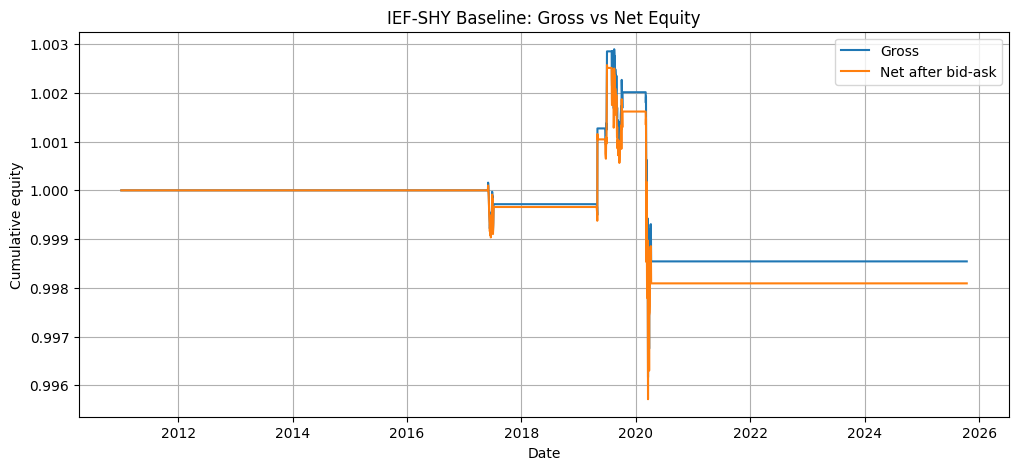

In [190]:
plt.figure(figsize=(12, 5))
plt.plot(
    baseline_run["wf_df"].index,
    baseline_run["wf_df"]["gross_equity_curve"],
    label="Gross"
)
plt.plot(
    baseline_run["wf_df"].index,
    baseline_run["wf_df"]["net_equity_curve"],
    label="Net after bid-ask"
)
plt.title("IEF-SHY Baseline: Gross vs Net Equity")
plt.xlabel("Date")
plt.ylabel("Cumulative equity")
plt.legend()
plt.grid(True)
plt.show()

In [191]:
candidate_pairs = screen_df[["ticker_1", "ticker_2", "pair", "corr", "coint_pvalue"]].head(10).copy()
candidate_pairs

,ticker_1,ticker_2,pair,corr,coint_pvalue
0,SPY US Equity,IWD US Equity,SPY US Equity | IWD US Equity,0.914431,3.018402e-15
1,XLK US Equity,IWF US Equity,XLK US Equity | IWF US Equity,0.966449,1.026042e-04
2,DIA US Equity,XLK US Equity,DIA US Equity | XLK US Equity,0.976489,1.309288e-03
3,XLI US Equity,XLK US Equity,XLI US Equity | XLK US Equity,0.927218,3.263152e-03
4,XLB US Equity,XLI US Equity,XLB US Equity | XLI US Equity,0.883679,3.471471e-03
5,IWM US Equity,IWD US Equity,IWM US Equity | IWD US Equity,0.874052,9.424006e-03
6,SPY US Equity,XLI US Equity,SPY US Equity | XLI US Equity,0.942911,2.360007e-02
7,XLE US Equity,IWF US Equity,XLE US Equity | IWF US Equity,0.929017,2.636260e-02
8,DIA US Equity,IWD US Equity,DIA US Equity | IWD US Equity,0.889440,2.715157e-02
9,QQQ US Equity,XLI US Equity,QQQ US Equity | XLI US Equity,0.956140,2.858745e-02
